P R O Y E C T O ABP 5



Autor: Alejandro González Cayuhan

Curso: Fundamentos de Análisis de Datos

L E C C I Ó N 1: Análisis Exploratorio de Datos ( E D A )

Carga y limpieza de datos


Se importa pandas para manipular dataset.

In [1]:
import pandas as pd

df = pd.read_csv("customer_shopping_data.csv")

¿Qué clase de objeto cargamos? Los siguientes códigos responden esta pregunta. 
Se apreciará una inspección visual, el tamaño del archivo y anatomía del dataset.
Aqui vemos qué variables sí sirven y cuales no, y cuales requieren transformación.

In [2]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [3]:
# Tamaño del dataset
df.shape

(99457, 10)

In [4]:
# Información y tipos de datos
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

NO hay nulos.

De aquí nos damos cuenta que invoice_date requiere modificación. Es un 'object'. Por tanto, ajustamos la fecha para poder trabajar bien con ella. 
Esto se hace para que Python no lo interprete mal.

In [5]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True)
df.info()
# Se realiza el cambio para trabajar adecuadamente con fecha.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB


Llama la atención desde ya conocer ciertas tendencias y las categorías existentes (DOMINANTES), por tanto, se ejecuta value.counts() para ver los primeros hallazgos

In [6]:
df["category"].value_counts()


category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

In [7]:
df["payment_method"].value_counts()

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

In [8]:
df["gender"].value_counts()

gender
Female    59482
Male      39975
Name: count, dtype: int64

PRIMEROS HALLAZGOS CATEGÓRICOS Clothing concentra mayor cantidad de transacciones, seguido de Cosmetics y Food&Beverage, lo que sugiere una fuerte orientación del consumo hacia productos de uso cotidiano y vesturario. En métodos de pago predomina Cash, lo que resulta interesante dado que el dataset incorpora compras asociadas a centros comerciales, lo cual podría reflejar una dinámica de compra presencial o híbrida. Y, en cuanto a Gender, existe mayor frecuencia a Female, pero se requiere mayor manejo de datos para concluir respecto a gastos. 

In [9]:
# Price no es precio individual, como se ve ahora:
df[["quantity", "price"]].head(10)

,quantity,price
0,5,1500.40
1,3,1800.51
2,1,300.08
3,5,3000.85
4,4,60.60
5,5,1500.40
6,1,40.66
7,2,600.16
8,3,900.24
9,2,600.16


Price representa valor total de la transacción por fila y NO es precio unitario. Se agregará una columna unit_price

In [10]:
# CREACIÓN DE NUEVA COLUMNA 
df["unit_price"] = df["price"] / df["quantity"]

In [11]:
# VERIFICACIÓN
df[["quantity", "price", "unit_price"]].head(10)

,quantity,price,unit_price
0,5,1500.40,300.08
1,3,1800.51,600.17
2,1,300.08,300.08
3,5,3000.85,600.17
4,4,60.60,15.15
5,5,1500.40,300.08
6,1,40.66,40.66
7,2,600.16,300.08
8,3,900.24,300.08
9,2,600.16,300.08


L E C C I Ó N 2: Conceptos básicos de Estadística Descriptiva

El objetivo es aplicar conceptos de tendencia central, dispersión y medidas de posición. Por tanto, usamos comando df.describe().

In [12]:
df[["age", "quantity", "price", "unit_price", "invoice_date"]].describe().round(2)

,age,quantity,price,unit_price,invoice_date
count,99457.00,99457.00,99457.00,99457.00,99457
mean,43.43,3.00,689.26,229.28,2022-02-04 02:46:59.783424
min,18.00,1.00,5.23,5.23,2021-01-01 00:00:00
25%,30.00,2.00,45.45,35.84,2021-07-19 00:00:00
50%,43.00,3.00,203.30,40.66,2022-02-05 00:00:00
75%,56.00,4.00,1200.32,300.08,2022-08-22 00:00:00
max,69.00,5.00,5250.00,1050.00,2023-03-08 00:00:00
std,14.99,1.41,941.18,266.05,NaN


CUARTILES PARA PRICE Q1 (25%) = 45.45 ; Q2 (50%) = 203.30 ; Q3 (75%) = 1200.32 

Las variables price y unit_price presentan distribución asimétrica positiva, evidenciada por una diferencia considerable entre media y mediana, lo que sugiere presencia de transacciones de alto valor que elevan el promedio general.

En contraste, Age y Quantity muestran comportamiento más estable y concentrado.

CALCULO DE VARIANZA Y PERCENTILES PARA 'PRICE':

In [13]:
# VARIANZA
df[["age", "quantity", "price", "unit_price"]].var().round(2)


age              224.70
quantity           2.00
price         885828.39
unit_price     70781.30
dtype: float64

'price' tiene varianza grande, lo que indica una ALTA dispersión de los datos: precios están muy extendidos.
'quantity' posee varianza baja: compras bastante estables en cantidad.

In [14]:
# PERCENTILES
df["price"].quantile([0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1]).round(2)

0.1      15.69
0.2      35.84
0.3      71.68
0.4     121.98
0.5     203.30
0.6     600.16
0.7     900.24
0.8    1200.32
0.9    1800.51
1.0    5250.00
Name: price, dtype: float64

OJO: desde percentil P50 (0.5) hay un salto fuerte. Pasamos de 203 -> 600 y así sigue subiendo. Existe fuerte concentración de precios bajos y dispersión creciente en niveles altos. 

HISTOGRAMA

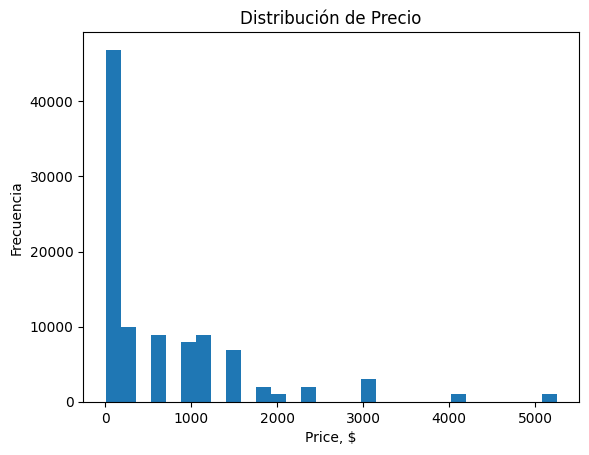

In [15]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=30)
plt.title("Distribución de Precio")
plt.xlabel("Price, $")
plt.ylabel("Frecuencia")
plt.show()

Esto muestra asimetría positiva (cola larga a la derecha o sesgo a la derecha). Alta frecuencia de precios bajos y baja frecuencia de precios altos.

Procedo a realizar BOXPLOTS

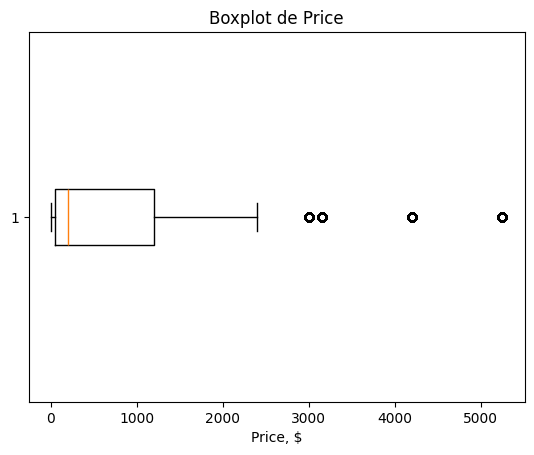

In [16]:
# H O R I Z O N T A L
plt.boxplot(df["price"], vert=False)
plt.title("Boxplot de Price")
plt.xlabel("Price, $")
plt.show()

La caja muestra Q1, Q2 (línea naranja) y Q3 descrito mas arriba: Q1 (25%) = 45.45 ; Q2 (50%) = 203.30 ; Q3 (75%) = 1200.32.

PRESENCIA DE OUTLIERS CERCANOS A 3000, 3200, 4200 Y 5250. Estas son compras muy superiores al comportamiento general de los datos.

In [17]:
# DESDE QUÉ VALOR SE CONSIDERA, MATEMATICAMENTE, OUTLIER:

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

print("Límite superior:", limite_superior)

Límite superior: 2932.625


L E C C I Ó N 3: CORRELACIÓN

A continuación, veremos la correlación (de Pearson) entre variables numéricas.

In [18]:
# CORRELACIÓN ENTRE VARIABLES (Coeficiente R de Pearson)
df[["age", "quantity", "price", "unit_price"]].corr()

,age,quantity,price,unit_price
age,1.000000,0.000667,0.001694,-0.000670
quantity,0.000667,1.000000,0.344880,0.001676
price,0.001694,0.344880,1.000000,0.850212
unit_price,-0.000670,0.001676,0.850212,1.000000


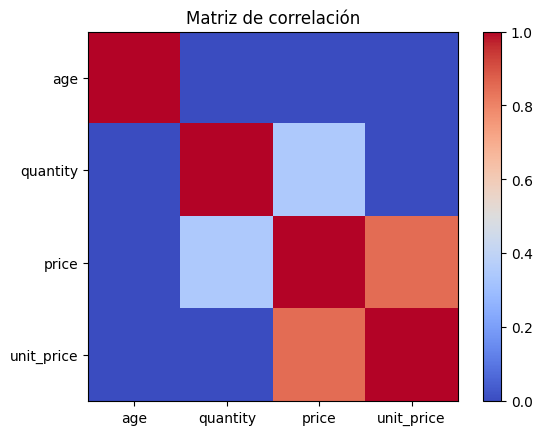

In [19]:
import matplotlib.pyplot as plt

corr = df[["age", "quantity", "price", "unit_price"]].corr()

plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de correlación")
plt.show()

SCATTERPLOT 

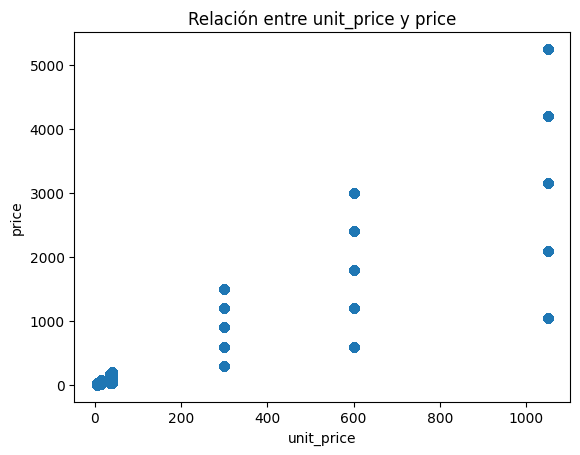

In [20]:
# SCATTERPLOT
plt.scatter(df["unit_price"], df["price"])
plt.title("Relación entre unit_price y price")
plt.xlabel("unit_price")
plt.ylabel("price")
plt.show()

Veamos ahora: SCATTERPLOT de 'quantity' vs 'price' (correlacion positiva moderada)

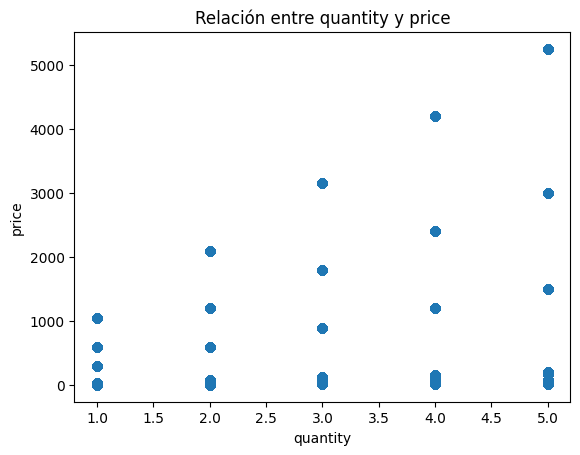

In [21]:
plt.scatter(df["quantity"], df["price"])
plt.title("Relación entre quantity y price")
plt.xlabel("quantity")
plt.ylabel("price")
plt.show()

Análisis o vista adicional: Boxplot para esta misma relacion 'quantity' vs 'price'

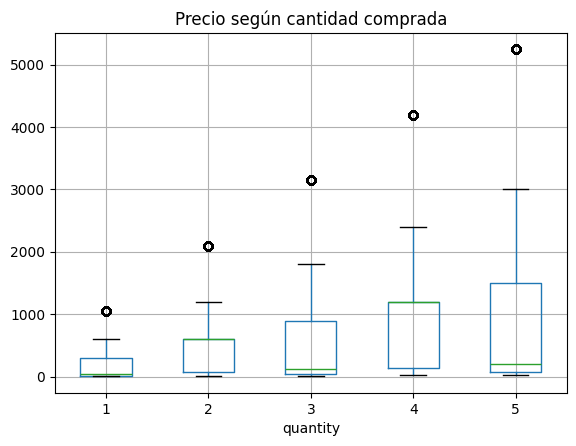

In [22]:
df.boxplot(column="price", by="quantity")
plt.title("Precio según cantidad comprada")
plt.suptitle("")
plt.show()

L E C C I Ó N 4: REGRESIONES LINEALES

MODELOS DE REGRESIÓN SIMPLE: PRICE & UNIT_PRICE, PRICE & QUANTITY+UNIT_PRICE+AGE

Regresión simple con statsmodels

In [23]:
import statsmodels.api as sm

X = df["unit_price"]
X = sm.add_constant(X)

y = df["price"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                 2.594e+05
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:04:30   Log-Likelihood:            -7.5831e+05
No. Observations:               99457   AIC:                         1.517e+06
Df Residuals:                   99455   BIC:                         1.517e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3622      2.074     -0.175      0.8

Como ya se ha visto, existe una relación lineal fuerte entre unit_price y price. Aquí R² = 0.723. Pero, price depende matemáticamente de unit_price. Este R² era esperable.

In [24]:
X = df[["quantity", "unit_price", "age"]]
X = sm.add_constant(X)

modelo2 = sm.OLS(y, X).fit()

print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                 1.751e+05
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:04:30   Log-Likelihood:            -7.3073e+05
No. Observations:               99457   AIC:                         1.461e+06
Df Residuals:                   99453   BIC:                         1.462e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -692.5291      4.556   -151.994      0.0

el modelo múltiple explica 84.1% de la variabilidad de price. 'age' no presenta significancia estadística en este modelo.

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred = modelo2.predict(X)

mse = mean_squared_error(y, pred)
mae = mean_absolute_error(y, pred)

print("MSE:", mse)
print("MAE:", mae)

MSE: 140999.61475015903
MAE: 247.30097405404632


<Axes: xlabel='unit_price', ylabel='price'>

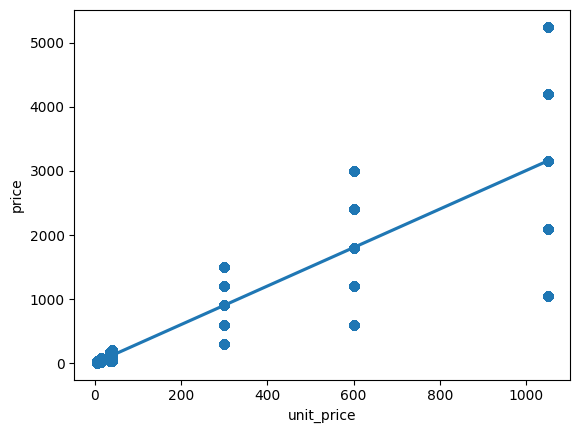

In [26]:
import seaborn as sns

sns.regplot(x="unit_price", y="price", data=df)

L E C C I Ó N 5: ANÁLISIS VISUAL DE DATOS


PAIRPLOT:

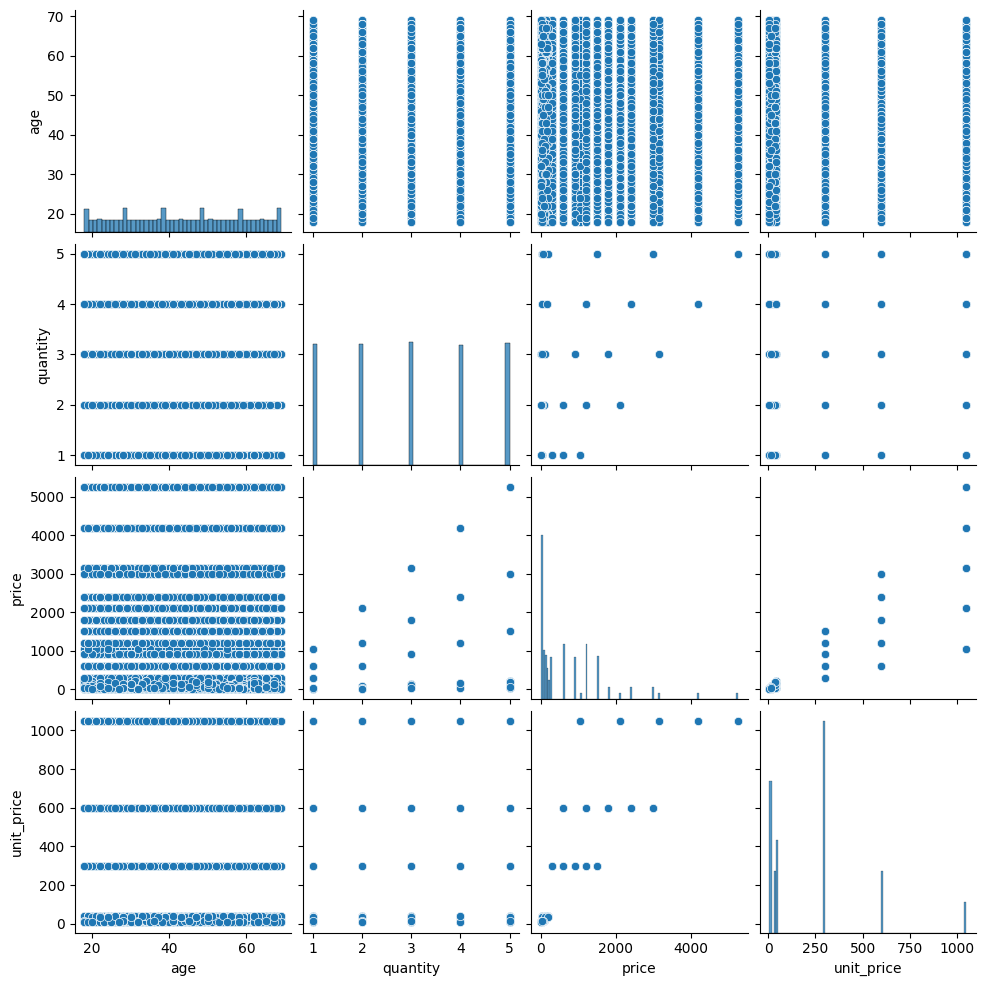

In [27]:
sns.pairplot(df[["age","quantity","price","unit_price"]])

Uso de una muestra de los datos:

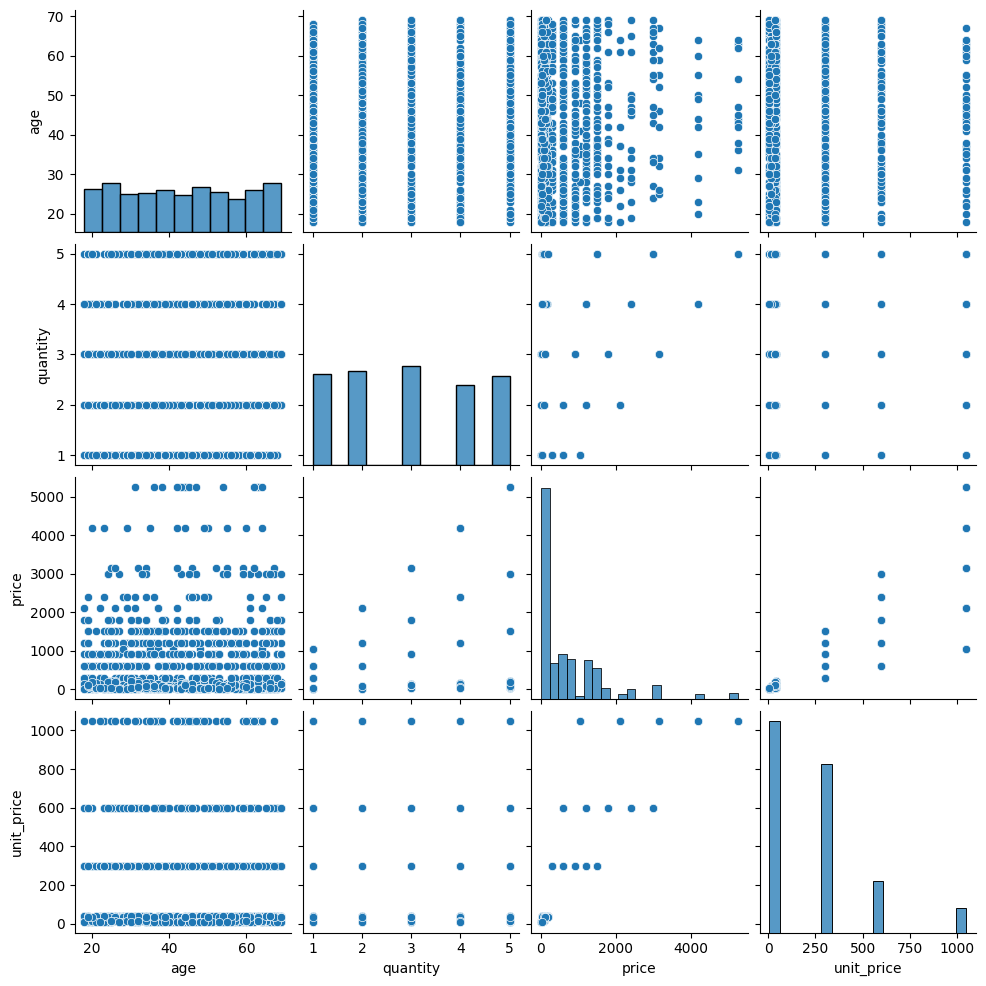

In [28]:
sns.pairplot(df[["age","quantity","price","unit_price"]].sample(1000))


JOINTPLOT:

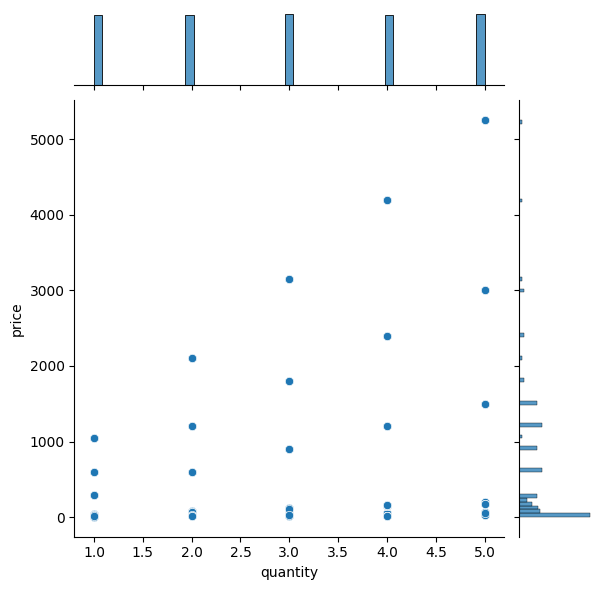

In [29]:
sns.jointplot(x="quantity", y="price", data=df)

quantity influye, pero el precio también depende fuertemente del precio unitario.

VIOLINPLOT PARA 'GENDER' Y 'PRICE':

<Axes: xlabel='gender', ylabel='price'>

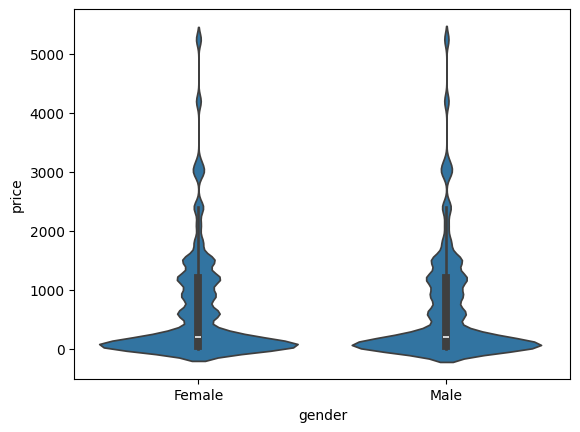

In [30]:
sns.violinplot(x="gender", y="price", data=df)

no hay diferencias fuertes en distribución de price por género.

VIOLINPLOT PARA 'PAYMENT_METHOD' Y 'PRICE':

<Axes: xlabel='payment_method', ylabel='price'>

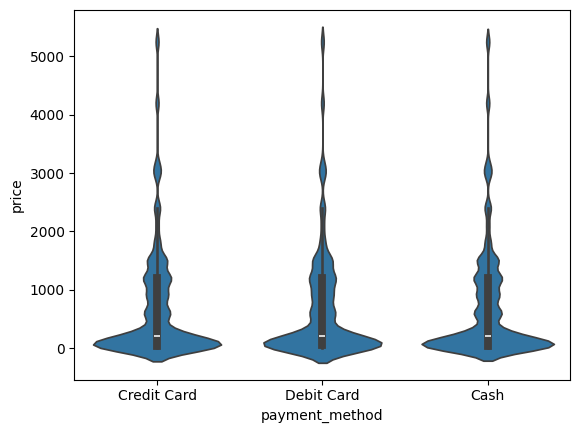

In [31]:
sns.violinplot(x="payment_method", y="price", data=df)

método de pago no cambia mucho el patrón de precios.

FacetGrid: 

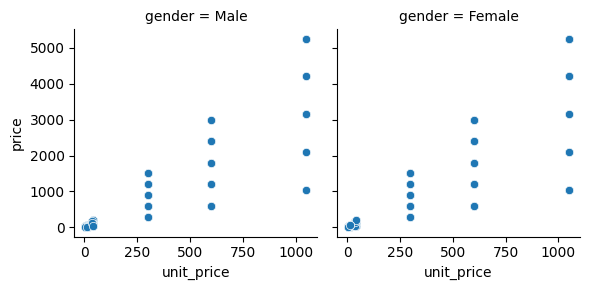

In [32]:
g = sns.FacetGrid(df.sample(1000), col="gender")
g.map_dataframe(sns.scatterplot, x="unit_price", y="price")

La distribución similar sugiere que el género no modifica de forma relevante el patrón de precios.

L E C C I Ó N 6: Librería Matplolib

HISTOGRAMA

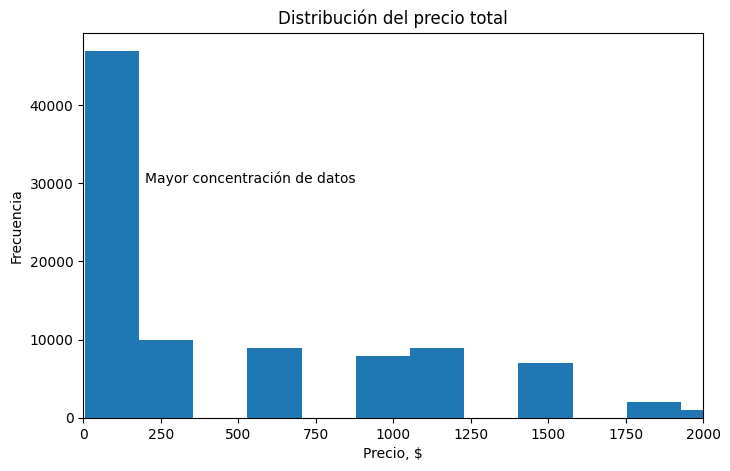

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("Distribución del precio total")
plt.xlabel("Precio, $")
plt.ylabel("Frecuencia")

plt.xlim(0,2000)

plt.annotate("Mayor concentración de datos",
             xy=(200, 25000),
             xytext=(200, 30000))

plt.savefig("histograma_final_price.png")

plt.show()

mucha concentración en precios bajos, cola larga hacia precios altos y outliers visibles.

SCATTER

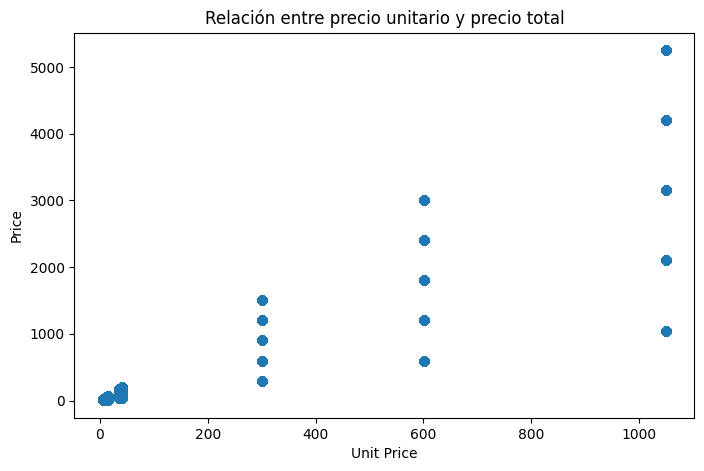

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(df["unit_price"], df["price"])

plt.title("Relación entre precio unitario y precio total")
plt.xlabel("Unit Price")
plt.ylabel("Price")

plt.savefig("scatter_unitprice_price.png")

plt.show()

relación lineal fuerte entre unit_price y price. Coincide con Pearson alto, R² alto Y coeficiente significativo en regresión.

BOXPLOT CATEGÓRICO

C:\Users\56977\AppData\Local\Temp\ipykernel_24712\1509894893.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


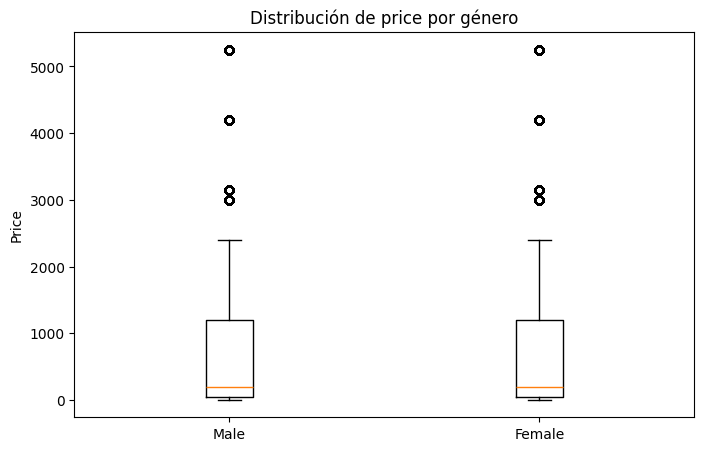

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [df[df["gender"]=="Male"]["price"],
     df[df["gender"]=="Female"]["price"]],
    labels=["Male","Female"]
)

plt.title("Distribución de price por género")
plt.ylabel("Price")

plt.savefig("boxplot_gender_price.png")

plt.show()

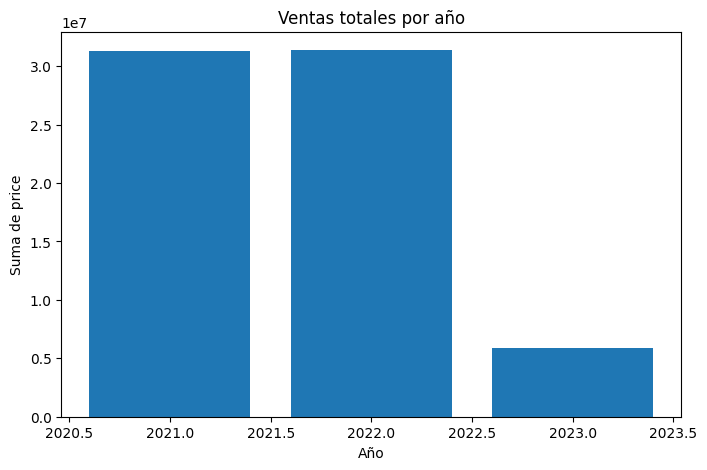

In [36]:
ventas_anio = df.groupby(df["invoice_date"].dt.year)["price"].sum()

plt.figure(figsize=(8,5))

plt.bar(ventas_anio.index, ventas_anio.values)

plt.title("Ventas totales por año")
plt.xlabel("Año")
plt.ylabel("Suma de price")

plt.savefig("ventas_por_anio.png")

plt.show()